# Part III: Cloud Radiative Effects

For Part III, the atmosphere is divided into three vertical layers:

1. Clear atmosphere above the cloud
2. Cloud layer
3. Clear atmosphere below the cloud

The atmosphere is defined from the surface to the top of atmosphere:

$$
z = 0
$$

at the surface, and

$$
z = z_{\text{atm}}
$$

at the top of atmosphere.

The cloud has a cloud-top height of

$$
z_{\text{cloud top}} = 1000 \ \text{m}
$$

and a cloud thickness of

$$
\Delta z_{\text{cloud}} = 250 \ \text{m}
$$

Therefore, the cloud base is

$$
z_{\text{cloud base}}
=
z_{\text{cloud top}} - \Delta z_{\text{cloud}}
$$

$$
z_{\text{cloud base}}
=
1000 - 250
=
750 \ \text{m}
$$

So the first clear atmosphere layer is:

$$
0 \leq z < 750 \ \text{m}
$$

then the cloud layer:

$$
750 \leq z < 1000 \ \text{m}
$$

and the last layer which is clear sky again:

$$
1000 \leq z \leq z_{\text{atm}}
$$





First, I'm going to define the properties of my cloud layer. From the notes, we have the cloud optical depth for a polydisperse cloud as:

$$
\tau_{\text{cloud}}
=
\frac{3L}{2\rho_l r_{\text{eff}}}
$$

where

$$
L
$$

is liquid water path,

$$
\rho_l
$$

is the density of liquid water,

and

$$
r_{\text{eff}}
$$

is the effective droplet radius.

The liquid water path is

$$
L = \text{LWC} \times \Delta z_{\text{cloud}}
$$

where LWC is liquid water content.

Here, we have:

$$
\text{LWC} = 0.30 \ \text{g m}^{-3} = 3 \times 10^{-4} \ \text{kg m}^{-3}
$$

so

$$
L =
3.0 \times 10^{-4}
\times
250
$$

$$
L = 0.075 \ \text{kg m}^{-2}
$$

The effective radius is:

$$
r_{\text{eff}} = 11 \ \mu\text{m} = 11 \times 10^{-6} \ \text{m}
$$

The density of liquid water is:

$$
\rho_l = 1000 \ \text{kg m}^{-3}
$$

Thus:

$$
\tau_{\text{cloud}}
=
\frac{3(0.075)}
{2(1000)(11 \times 10^{-6})}
$$

$$
\tau_{\text{cloud}}
\approx 10.23
$$

In [9]:
######### Define cloud parameters #########
cloud_top = 1000      # m
cloud_thickness = 250 # m
cloud_base = cloud_top - cloud_thickness
reff = 11e-6       # m
LWC = 3.0e-4      # kg/m^3, because 0.30 g/m^3 = 0.30e-3 kg/m^3
cloud_thickness = 250  # m
density = 1000       # kg/m^3
L = LWC * cloud_thickness  # kg/m^2
tau_cloud = 3 * L / (2 * density * reff)

print(tau_cloud)

10.227272727272727


The coordinate rotation function stays the same as before.

In [10]:
import numpy as np 
import matplotlib.pyplot as plt

#########Define the function to get the incoming photon direction, change it to photon coordinates, and change it back to the new photon direction
def coordinate_rotation_non_isotropic(k, g):


    # Incoming photon coordinate system
    zp = k 

    kx, ky, kz = zp

    # Define xp
    horizontal_norm = np.sqrt(kx**2 + ky**2)

    if horizontal_norm < 1e-10:  # For the special case when photon is nearly vertical
        xp = np.array([1.0, 0.0, 0.0])
    else:
        xp = np.array([-ky, kx, 0.0]) / horizontal_norm

    # Define yp
    yp = np.cross(zp, xp)

    # Draw non-isotropic scattering angles
    zeta = np.random.uniform(0, 1)

    if abs(g) < 1e-12:
        cos_theta = 2 * zeta - 1 #isotropic scattering
    else:
        cos_theta = (1 / (2 * g)) * (
            1 + g**2
            - ((1 - g**2) / (1 - g + 2 * g * zeta))**2 #non-isotropic scattering
        )
    # Numerical safety to make sure cos theta is in the valid range [-1, 1]
    cos_theta = np.clip(cos_theta, -1, 1)
    sin_theta = np.sqrt(1 - cos_theta**2)
    phi = 2 * np.pi * np.random.uniform(0,1)

    # Scattered direction in photon coordinates
    kp = np.array([
        sin_theta * np.cos(phi),
        sin_theta * np.sin(phi),
        cos_theta
    ])


    # Rotate back into model coordinates
    knew = kp[0] * xp + kp[1] * yp + kp[2] * zp

    return knew

For the clear sky above and below the cloud, the optical depth can change as a function of atmospheric pressure. Because atmospheric pressure decreases with height, most of the atmospheric mass is near the surface. We can approximate the vertical pressure profile using an exponential atmosphere:

$$
p(z) = p_0 e^{-z/H}
$$

where \(p(z)\) is pressure at height \(z\), \(p_0\) is surface pressure, and \(H\) is the atmospheric scale height. A typical value is:

$$
H \approx 8000 \ \text{m}
$$

which is also the height of out atmosphere. Since clear-sky optical depth is assumed to be proportional to atmospheric pressure, the fraction of clear-sky optical depth in a layer from $\ (z_{\text{bottom}})$ to $\ (z_{\text{top}})$ is:

$$
f_{\text{layer}}
=
\frac{
p(z_{\text{bottom}}) - p(z_{\text{top}})
}{
p(0) - p(z_{\text{atm}})
}
$$


If the total clear-sky optical depth from the surface to the top of the atmosphere is

$$
\tau_{\text{clear,total}}
$$

then the clear-sky optical depth of a specific layer is

$$
\tau_{\text{clear,layer}}
=
\tau_{\text{clear,total}}
f_{\text{layer}}
$$

or

$$
\tau_{\text{clear,layer}}
=
\tau_{\text{clear,total}}
\frac{
e^{-z_{\text{bottom}}/H} - e^{-z_{\text{top}}/H}
}{
1 - e^{-z_{\text{atm}}/H}
}
$$

For the layer below the cloud:


$$
\tau_{\text{clear,below}}
=
\tau_{\text{clear,total}}
\frac{
1 - e^{-z_{\text{cloud base}}/H}
}{
1 - e^{-z_{\text{atm}}/H}
}
$$

For the layer above the cloud:


$$
\tau_{\text{clear,above}}
=
\tau_{\text{clear,total}}
\frac{
e^{-z_{\text{cloud top}}/H} - e^{-z_{\text{atm}}/H}
}{
1 - e^{-z_{\text{atm}}/H}
}
$$

Here I'll assume the total optical depth is 0.1 and calculate the optical depth of each clear sky layer based on that. Also, I will define 3 atmospheric layers and calculate their extinction coefficients respectively to be used in the model based on the layer we are in.

In [11]:
########Define optical depth for clear sky as a function of pressure############
import numpy as np
import pandas as pd
def pressure(z_bottom, z_top, z_atm, H=8000):
    p_bottom = np.exp(-z_bottom / H)
    p_top = np.exp(-z_top / H)
    p_surface = 1.0
    p_toa = np.exp(-z_atm / H)

    return (p_bottom - p_top) / (p_surface - p_toa)

tau_clear_total = 0.1
z_atm = 8000
frac_above = pressure(cloud_top, z_atm, z_atm, z_atm)
frac_below = pressure(0, cloud_base, z_atm, z_atm)

tau_clear_above = tau_clear_total * frac_above
tau_clear_below = tau_clear_total * frac_below

#layer list
layers = [
    {
        "name": "clear_below",
        "z_bottom": 0.0,
        "z_top": cloud_base,
        "tau": tau_clear_below,
        "omega": 1.0,
        "g": 0.0
    },
    {
        "name": "cloud",
        "z_bottom": cloud_base,
        "z_top": cloud_top,
        "tau": tau_cloud,
        "omega": 1.0,
        "g": 0.8
    },
    {
        "name": "clear_above",
        "z_bottom": cloud_top,
        "z_top": z_atm,
        "tau": tau_clear_above,
        "omega": 1.0,
        "g": 0.0
    }
]

for layer in layers:
    layer["thickness"] = layer["z_top"] - layer["z_bottom"]
    layer["beta_e"] = layer["tau"] / layer["thickness"]

pd.DataFrame(layers)

,name,z_bottom,z_top,tau,omega,g,thickness,beta_e
0,clear_below,0.0,750,0.014157,1.0,0.0,750.0,0.000019
1,cloud,750.0,1000,10.227273,1.0,0.8,250.0,0.040909
2,clear_above,1000.0,8000,0.081411,1.0,0.0,7000.0,0.000012


Here I'll again start defining the core monte carlo function. The difference between this and the previous model is that we now have boundaries in addition to surface and TOA. If the photon reaches an internal layer boundary, such as the cloud top or cloud base, the photon is not finished. It simply enters the next layer and continues traveling. The photon is only finished if it reaches:

Surface:

$$
z \leq 0
$$

or top of atmosphere:

$$
z \geq z_{\text{atm}}
$$

If the photon reaches the surface, it contributes to surface transmittance. If the photon exits the top of atmosphere, it contributes to albedo. I have modified the model a little to add the fact that our atmosphere now has three different layers. In the model below, each photon is first assigned a random traveled optical depth and the geometric pathlength that it would travel is calculated based on the parameters of the first top layer of clear sky. Then, the model would decide if the photon is extinct before reaching the lower level or it would reach that level first before extinction. This process will be repeated for each photon until they are either transmitted to the surface or reflected back to the space.

In [12]:
#####helper to find the atmospheric layer
def get_layer(z, layers):
    eps = 1e-9

    for layer in layers:
        if layer["z_bottom"] - eps <= z <= layer["z_top"] + eps:
            return layer

    return None



########Define the model 


def monte_carlo_scattering(N, theta_deg, z_atm, phi_deg=0, max_scatter=1000):
    
    theta0 = np.radians(theta_deg)
    phi0 = np.radians(phi_deg)

    if theta_deg >= 90:
        raise ValueError("Theta must be less than 90 degrees.")
    
    # Initial direction vector
    k0 = np.array([
        np.cos(phi0) * np.sin(theta0),
        np.sin(phi0) * np.sin(theta0),
        -np.cos(theta0)
    ])
    
    # Arrays to store photons' traveled pathlengths
    final_pathlength = np.zeros(N)
    
    # Stores how many times each photon scatters
    scatter_counts = np.zeros(N, dtype=int)
    
    # Stores the final fate of each photon
    photon_fate = np.array(["unfinished"] * N, dtype=object)

    # Store the first extinction height for each photon
    first_extinction_height = np.full(N, np.nan)
    
    for i in range(N):

        # Set the height of the photon to the top of the atmosphere
        z = z_atm
        k = k0.copy()

        alive = True
        has_had_extinction = False

        while alive:

            # Find the current layer the photon is in
            layer = get_layer(z, layers)

            if layer is None:
                photon_fate[i] = "lost"
                alive = False
                break
            
            # Extinction coefficient and other parameters for the current layer
            beta_e = layer["beta_e"]
            omega = layer["omega"]
            g = layer["g"]
            
            
            #Sample pathlength to next extinction event
            

            zeta = np.random.uniform(0, 1)

            # Optical depth traveled before extinction
            tau_traveled = -np.log(1 - zeta)

            # Convert optical pathlength to geometric pathlength
            if beta_e > 0:
                geometric_pathlength = tau_traveled / beta_e
            else:
                geometric_pathlength = np.inf
        
           
            #Compute distance to next layer boundary
            

            if k[2] < 0:
                distance_to_boundary = (z - layer["z_bottom"]) / abs(k[2])
                boundary_z = layer["z_bottom"]

            elif k[2] > 0:
                distance_to_boundary = (layer["z_top"] - z) / k[2]
                boundary_z = layer["z_top"]

            else:
                distance_to_boundary = np.inf
                boundary_z = None
                
            
            #Boundary happens before extinction
            

            if geometric_pathlength >= distance_to_boundary:

                final_pathlength[i] += distance_to_boundary
                z = boundary_z
                
                # If boundary is surface
                if z <= 0:
                    if scatter_counts[i] == 0:
                        photon_fate[i] = "direct_surface"
                    else:
                        photon_fate[i] = "diffuse_surface"

                    alive = False

                # If boundary is top of atmosphere
                elif z >= z_atm:
                    photon_fate[i] = "reflected"
                    alive = False

                # If internal boundary, move into next layer
                else:
                    z = z + 1e-8 * np.sign(k[2])
                    
            
            #Extinction happens before boundary
            

            else:
                final_pathlength[i] += geometric_pathlength

                # Move photon to extinction location
                z = z + geometric_pathlength * k[2]

                # Store first extinction height
                if not has_had_extinction:
                    first_extinction_height[i] = z
                    has_had_extinction = True
                
                # Decide scattering or absorption
                if np.random.uniform(0, 1) < omega:
                    # Scattering event
                    k = coordinate_rotation_non_isotropic(k, g)
                    scatter_counts[i] += 1

                    if scatter_counts[i] > max_scatter:
                        photon_fate[i] = "max_scatter_reached"
                        alive = False

                else:
                    # Absorption event
                    photon_fate[i] = "absorbed"
                    alive = False
    
    # Store the results
    N_direct_surface = np.sum(photon_fate == "direct_surface")
    N_diffuse_surface = np.sum(photon_fate == "diffuse_surface")
    N_reflected = np.sum(photon_fate == "reflected")
    N_absorbed_atm = np.sum(photon_fate == "absorbed")
    N_max_scatter = np.sum(photon_fate == "max_scatter_reached")
    N_lost = np.sum(photon_fate == "lost")

    total_tau = np.sum([layer["tau"] for layer in layers])
    
    results = {
        "N": N,
        "total_tau": total_tau,
        "theta_deg": theta_deg,
        "phi_deg": phi_deg,
        "mu0": np.abs(k0[2]),
        "layers": layers,

        "N_direct_surface": N_direct_surface,
        "N_diffuse_surface": N_diffuse_surface,
        "N_reflected": N_reflected,
        "N_absorbed_atm": N_absorbed_atm,
        "N_max_scatter": N_max_scatter,
        "N_lost": N_lost,

        "direct_transmittance": N_direct_surface / N,
        "diffuse_transmittance": N_diffuse_surface / N,
        "total_surface_transmittance": (N_direct_surface + N_diffuse_surface) / N,
        "albedo": N_reflected / N,
        "atmospheric_absorptance": N_absorbed_atm / N,
        "max_scatter_fraction": N_max_scatter / N,
        "lost_fraction": N_lost / N,

        "photons fate": photon_fate,
        "final_pathlength": final_pathlength,
        "first_extinction_height": first_extinction_height,
        "scatter_counts": scatter_counts
    }
    
    return results

In [13]:
##### Helper to print a summary table of the results
import pandas as pd
def summary(results):
    summary_keys = [
        "N",
        "total_tau",
        "theta_deg",
        "phi_deg",
        "mu0",
        "layers",
        "N_direct_surface",
        "N_diffuse_surface",
        "N_reflected",
        "N_absorbed_atm",
        "N_max_scatter",
        "N_lost",
        "direct_transmittance",
        "diffuse_transmittance",
        "total_surface_transmittance",
        "albedo",
        "atmospheric_absorptance",
        "max_scatter_fraction",
        "lost_fraction",
        "photons fate",
        "final_pathlength",
        "first_extinction_height",
        "scatter_counts"
    ]

    summary_table = pd.DataFrame({
        "quantity": summary_keys,
        "value": [results[key] for key in summary_keys]
    })

    return summary_table

# Validation 1

For the first test, I'm going tto temporarily set the single scattering albedo of the cloud to zero. In this scenario, the cloud is purely absorbing and the surface transmittance should be close to zero and most of our photons should be absorbed since our cloud is optically very thick. Since the above layer of the clear sky is still purely scattering, we should also see some fraction of photons reflected back to the space, which is 0.03 in this case.

In [ ]:
results = monte_carlo_scattering(100000, 0, 8000, 0, max_scatter=1000) #(N, theta_deg, z_atm, phi_deg=0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,100000
1,total_tau,10.322841
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,layers,"[{'name': 'clear_below', 'z_bottom': 0.0, 'z_t..."
6,N_direct_surface,4
7,N_diffuse_surface,0
8,N_reflected,3727
9,N_absorbed_atm,96269


# Validation 2

For the second test, I will set the optical depth of my cloud layer to 1 and also I will set the single scattering albedo of all layers to zero to make thr atmosphere purely absorbing. In this case, the direct transmittance should match the beer's law and what we have seen previously for validation 1 of Part I of this homework, which is approximately 0.36. Here, we get a direct transmittance of 0.33, which is fair considering the slight difference in the structure of optical depth between this case and a homogeneous purely absorbing atmosphere. In addition, we also see that the albedo is zero, as expected.

In [45]:
results = monte_carlo_scattering(100000, 0, 8000, 0, max_scatter=1000) #(N, theta_deg, z_atm, phi_deg=0, max_scatter=1000)
summary_table = summary(results)
summary_table

,quantity,value
0,N,100000
1,total_tau,1.095568
2,theta_deg,0
3,phi_deg,0
4,mu0,1.0
5,layers,"[{'name': 'clear_below', 'z_bottom': 0.0, 'z_t..."
6,N_direct_surface,33297
7,N_diffuse_surface,0
8,N_reflected,0
9,N_absorbed_atm,66703


# Question a


The shortwave cloud radiative effect at the top of atmosphere is defined as the difference between cloudy-sky and clear-sky net shortwave radiation:

$$
CRE_{\text{SW,TOA}}
=
F_{\text{net,cloudy}} - F_{\text{net,clear}}
$$

At the top of atmosphere, the net downward shortwave flux is the incoming solar flux minus the reflected shortwave flux:

$$
F_{\text{net}}
=
F_0 \mu_0 (1-\alpha)
$$

where $\ F_0$ is the incoming solar constant shortwave radiation,  $\mu_0 = \cos\theta_0$ , and $ \alpha$ is the planetary albedo from the Monte Carlo model.

Therefore:

$$
CRE_{\text{SW,TOA}}
=
F_0 \mu_0 (1-\alpha_{\text{cloudy}})
-
F_0 \mu_0 (1-\alpha_{\text{clear}})
$$

This simplifies to:

$$
CRE_{\text{SW,TOA}}
=
-F_0 \mu_0
\left(
\alpha_{\text{cloudy}} - \alpha_{\text{clear}}
\right)
$$

or:

$$
CRE_{\text{SW,TOA}}
=
-F_0 \mu_0 \Delta \alpha
$$

where:

$$
\Delta \alpha =
\alpha_{\text{cloudy}} - \alpha_{\text{clear}}
$$

In the model, the cloud increases the albedo relative to clear sky. Therefore, $ \Delta \alpha > 0$, which makes:

$$
CRE_{\text{SW,TOA}} < 0
$$

The model shows albedo of 0.526 with clouds and 0.046 for clear sky. Knowing that the incoming solar flux is 1361 $\ W/m^2$, this results in cloud shortwave radiative forcing of approximately -625 $\ W/m^2$. This negative shortwave cloud radiative effect means that the cloud reflects more incoming solar radiation back to space and cools the Earth-atmosphere system.

In [ ]:
################Cloudy case with the cloud layer defined above
# Solar constant
F0 = 1361  # W/m^2
theta_deg = 0
mu0 = np.cos(np.radians(theta_deg))
results_cloudy = monte_carlo_scattering(
    N=100000,
    theta_deg=theta_deg,
    z_atm=8000,
    phi_deg=0,
    max_scatter=10000
)

alpha_cloudy = results_cloudy["albedo"]
print(f"Cloudy case albedo: {alpha_cloudy:.4f}")

Cloudy case albedo: 0.5260


In [8]:
############Define clear-sky atmosphere
theta_deg = 0
mu0 = np.cos(np.radians(theta_deg))
layers = [
    {
        "name": "clear",
        "z_bottom": 0.0,
        "z_top": 8000.0,
        "tau": tau_clear_total,
        "omega": 1.0,
        "g": 0.0
    }
]

for layer in layers:
    layer["thickness"] = layer["z_top"] - layer["z_bottom"]
    layer["beta_e"] = layer["tau"] / layer["thickness"]

results_clear = monte_carlo_scattering(
    N=100000,
    theta_deg=theta_deg,
    z_atm=8000,
    phi_deg=0,
    max_scatter=10000
)

alpha_clear = results_clear["albedo"]
print(f"Clear-sky case albedo: {alpha_clear:.4f}")

Clear-sky case albedo: 0.0478


In [52]:
CRE_SW_TOA = -F0 * mu0 * (alpha_cloudy - alpha_clear)

print("Clear-sky albedo:", alpha_clear)
print("Cloudy-sky albedo:", alpha_cloudy)
print("Delta albedo:", alpha_cloudy - alpha_clear)
print("SW CRE at TOA:", CRE_SW_TOA, "W/m^2")

Clear-sky albedo: 0.04665
Cloudy-sky albedo: 0.526
Delta albedo: 0.47935000000000005
SW CRE at TOA: -652.3953500000001 W/m^2


# Question b

In this part, I'll vary the effective radius between 5.5 to 22 microns and calculate the monte carlo albedo for ech case. We also have the clear sky albedo from the previous question and therefore the SW CRE could be calculated for each effective radius case. When the number of cloud condensation nuclei in a cloud increases and with keeping the LWC constant, the amount of water vapor that condensed around each nuclei is reduced. Therefore, the effective radius of the CCN is smaller. As the CNN number decreases (less polluted environments), the available water vapor that can condense around each particle is increased and thus, the effective radius is increased. As the effective radius is increased, the cloud optical depth gets smaller and this reduces the albedo caused by the cloud. As the effective radius decreases with the increased number of CCN, the optical depth of cloud becomes larger, which results in larger albedo of SW. This shows the aerosol indirect effect through the clouds.  


In [54]:
# Reff sweep: half to double initial value
reff_values = np.linspace(0.5 * reff, 2.0 * reff, 10)

rows = []

for reff in reff_values:

    # Cloud optical depth for this effective radius
    tau_cloud = 3 * L / (2 * density * reff)

    # Update cloudy layers
    layers[0]["tau"] = tau_clear_below
    layers[0]["omega"] = 1.0
    layers[0]["g"] = 0.0

    layers[1]["tau"] = tau_cloud
    layers[1]["omega"] = 1.0
    layers[1]["g"] = 0.8

    layers[2]["tau"] = tau_clear_above
    layers[2]["omega"] = 1.0
    layers[2]["g"] = 0.0

    # Recalculate beta_e after changing tau
    for layer in layers:
        layer["thickness"] = layer["z_top"] - layer["z_bottom"]
        layer["beta_e"] = layer["tau"] / layer["thickness"]

    results_cloudy = monte_carlo_scattering(
        N=100000,
        theta_deg=theta_deg,
        z_atm=z_atm,
        phi_deg=0,
        max_scatter=10000
    )

    alpha_cloudy = results_cloudy["albedo"]

    CRE_SW_TOA = -F0 * mu0 * (alpha_cloudy - alpha_clear)

    rows.append({
        "reff_m": reff,
        "reff_um": reff * 1e6,
        "tau_cloud": tau_cloud,
        "alpha_clear": alpha_clear,
        "alpha_cloudy": alpha_cloudy,
        "CRE_SW_TOA": CRE_SW_TOA
    })

cre_reff_df = pd.DataFrame(rows)
cre_reff_df

,reff_m,reff_um,tau_cloud,alpha_clear,alpha_cloudy,CRE_SW_TOA
0,0.000005,5.500000,20.454545,0.04665,0.69985,-889.00520
1,0.000007,7.333333,15.340909,0.04665,0.63029,-794.33404
2,0.000009,9.166667,12.272727,0.04665,0.57562,-719.92817
3,0.000011,11.000000,10.227273,0.04665,0.52832,-655.55287
4,0.000013,12.833333,8.766234,0.04665,0.48485,-596.39020
5,0.000015,14.666667,7.670455,0.04665,0.44742,-545.44797
6,0.000017,16.500000,6.818182,0.04665,0.41774,-505.05349
7,0.000018,18.333333,6.136364,0.04665,0.38696,-463.16191
8,0.000020,20.166667,5.578512,0.04665,0.36449,-432.58024
9,0.000022,22.000000,5.113636,0.04665,0.34410,-404.82945


Slope = 28.68 W m^-2 um^-1
Intercept = -995.00 W m^-2


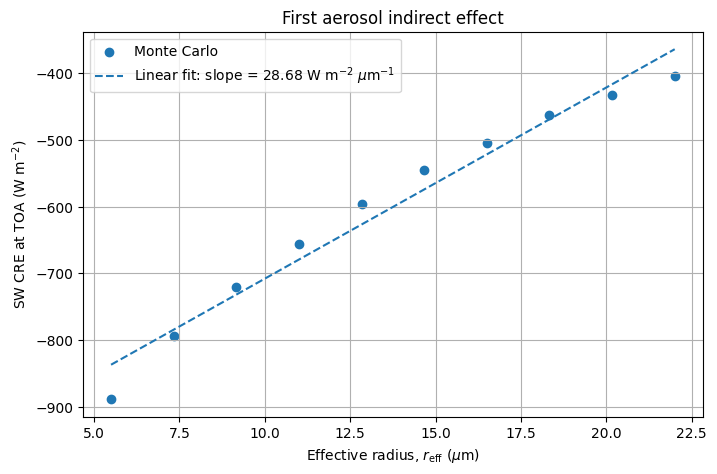

In [55]:
slope, intercept = np.polyfit(
    cre_reff_df["reff_um"],
    cre_reff_df["CRE_SW_TOA"],
    1
)

print(f"Slope = {slope:.2f} W m^-2 um^-1")
print(f"Intercept = {intercept:.2f} W m^-2")

x_fit = np.linspace(
    cre_reff_df["reff_um"].min(),
    cre_reff_df["reff_um"].max(),
    100
)

y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 5))

plt.scatter(
    cre_reff_df["reff_um"],
    cre_reff_df["CRE_SW_TOA"],
    label="Monte Carlo"
)

plt.plot(
    x_fit,
    y_fit,
    linestyle="--",
    label=fr"Linear fit: slope = {slope:.2f} W m$^{{-2}}$ $\mu$m$^{{-1}}$"
)

plt.xlabel(r"Effective radius, $r_{\mathrm{eff}}$ ($\mu$m)")
plt.ylabel(r"SW CRE at TOA (W m$^{-2}$)")
plt.title(r"First aerosol indirect effect")
plt.grid(True)
plt.legend()
plt.show()


# Question c

My question: What would happen to the CRE if we move the cloud to higher altitudes from 1000m to 7000m? 
Hypothesis: Changing cloud-top height from 1000 m to 7000 m should not change the shortwave CRE as strongly as changing cloud droplet effective radius, because the cloud optical depth is held constant. However, as the cloud moves higher, the clear-sky layer above the cloud becomes thinner. Since the clear-sky layer scatters isotropically while the cloud is strongly forward-scattering with \(g=0.8\), less above-cloud isotropic scattering may slightly reduce the amount of radiation reflected back to space. Therefore, the magnitude of the negative SW CRE may become slightly smaller as cloud height increases. The model results show that the CRE could actually get smaller in magnitude as the cloud moves higher, but the effect seems to be very small (around 6 units of CRE) and not consistently dropping as the height increases.

In [15]:
cloud_top_values = np.arange(1000, 7000 + 500, 500)
F0 = 1361  # W/m^2
theta_deg = 0
mu0 = np.cos(np.radians(theta_deg))
rows = []

for cloud_top_value in cloud_top_values:

    cloud_base = cloud_top_value - cloud_thickness

    frac_above = pressure(
        z_bottom=cloud_top_value,
        z_top=z_atm,
        z_atm=z_atm,
        H=8000
    )

    frac_below = pressure(
        z_bottom=0,
        z_top=cloud_base,
        z_atm=z_atm,
        H=8000
    )

    tau_clear_above = tau_clear_total * frac_above
    tau_clear_below = tau_clear_total * frac_below

    layers = [
        {
            "name": "clear_below",
            "z_bottom": 0.0,
            "z_top": cloud_base,
            "tau": tau_clear_below,
            "omega": 1.0,
            "g": 0.0
        },
        {
            "name": "cloud",
            "z_bottom": cloud_base,
            "z_top": cloud_top_value,
            "tau": tau_cloud,
            "omega": 1.0,
            "g": 0.8
        },
        {
            "name": "clear_above",
            "z_bottom": cloud_top_value,
            "z_top": z_atm,
            "tau": tau_clear_above,
            "omega": 1.0,
            "g": 0.0
        }
    ]

    for layer in layers:
        layer["thickness"] = layer["z_top"] - layer["z_bottom"]
        layer["beta_e"] = layer["tau"] / layer["thickness"]

    results_cloudy = monte_carlo_scattering(
        N=100000,
        theta_deg=theta_deg,
        z_atm=z_atm,
        phi_deg=0,
        max_scatter=10000
    )

    alpha_cloudy = results_cloudy["albedo"]

    CRE_SW_TOA = -F0 * mu0 * (alpha_cloudy - alpha_clear)

    rows.append({
        "cloud_top": cloud_top_value,
        "cloud_base": cloud_base,
        "tau_cloud": tau_cloud,
        "tau_clear_above": tau_clear_above,
        "tau_clear_below": tau_clear_below,
        "alpha_clear": alpha_clear,
        "alpha_cloudy": alpha_cloudy,
        "CRE_SW_TOA": CRE_SW_TOA,
        "surface_transmittance": results_cloudy["total_surface_transmittance"]
    })

cre_height_df = pd.DataFrame(rows)
cre_height_df

,cloud_top,cloud_base,tau_cloud,tau_clear_above,tau_clear_below,alpha_clear,alpha_cloudy,CRE_SW_TOA,surface_transmittance
0,1000,750,10.227273,0.081411,0.014157,0.04775,0.52866,-654.51851,0.47134
1,1500,1250,10.227273,0.072953,0.022884,0.04775,0.52618,-651.14323,0.47382
2,2000,1750,10.227273,0.065007,0.031082,0.04775,0.52630,-651.30655,0.47370
3,2500,2250,10.227273,0.057542,0.038784,0.04775,0.52618,-651.14323,0.47382
4,3000,2750,10.227273,0.050530,0.046019,0.04775,0.52739,-652.79004,0.47261
5,3500,3250,10.227273,0.043942,0.052815,0.04775,0.52599,-650.88464,0.47401
6,4000,3750,10.227273,0.037754,0.059200,0.04775,0.52694,-652.17759,0.47306
7,4500,4250,10.227273,0.031941,0.065198,0.04775,0.52667,-651.81012,0.47333
8,5000,4750,10.227273,0.026479,0.070833,0.04775,0.52496,-649.48281,0.47504
9,5500,5250,10.227273,0.021349,0.076126,0.04775,0.52541,-650.09526,0.47459


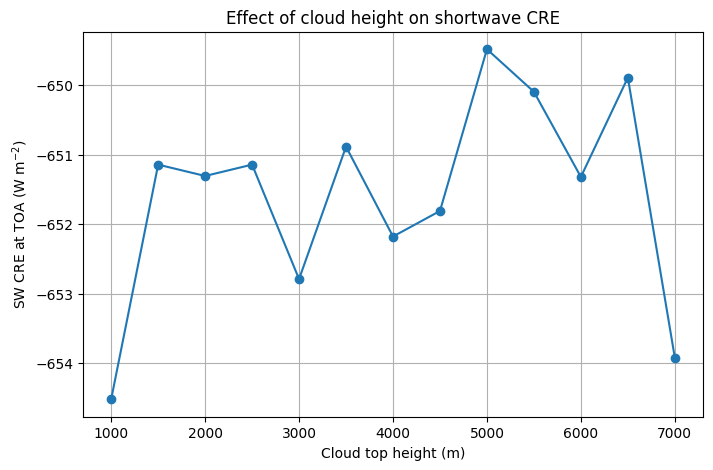

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    cre_height_df["cloud_top"],
    cre_height_df["CRE_SW_TOA"],
    marker="o"
)

plt.xlabel("Cloud top height (m)")
plt.ylabel(r"SW CRE at TOA (W m$^{-2}$)")
plt.title("Effect of cloud height on shortwave CRE")
plt.grid(True)
plt.show()

Now if we increase the thickness of the cloud while keeping LWC constant, the liquid water path and thus, the cloud optical depth will increase. As a result, we should see higher magnitudes of CRE as the cloud thickness increases.

In [17]:
cloud_thickness_values = np.arange(250, 1000, 250)
F0 = 1361  # W/m^2
theta_deg = 0
mu0 = np.cos(np.radians(theta_deg))
rows = []

for cloud_thickness in cloud_thickness_values:
    L = LWC * cloud_thickness  # kg/m^2
    tau_cloud = 3 * L / (2 * density * reff)
    cloud_base = 750
    cloud_top_value = cloud_base + cloud_thickness

    frac_above = pressure(
        z_bottom=cloud_top_value,
        z_top=z_atm,
        z_atm=z_atm,
        H=8000
    )

    frac_below = pressure(
        z_bottom=0,
        z_top=cloud_base,
        z_atm=z_atm,
        H=8000
    )

    tau_clear_above = tau_clear_total * frac_above
    tau_clear_below = tau_clear_total * frac_below

    layers = [
        {
            "name": "clear_below",
            "z_bottom": 0.0,
            "z_top": cloud_base,
            "tau": tau_clear_below,
            "omega": 1.0,
            "g": 0.0
        },
        {
            "name": "cloud",
            "z_bottom": cloud_base,
            "z_top": cloud_top_value,
            "tau": tau_cloud,
            "omega": 1.0,
            "g": 0.8
        },
        {
            "name": "clear_above",
            "z_bottom": cloud_top_value,
            "z_top": z_atm,
            "tau": tau_clear_above,
            "omega": 1.0,
            "g": 0.0
        }
    ]

    for layer in layers:
        layer["thickness"] = layer["z_top"] - layer["z_bottom"]
        layer["beta_e"] = layer["tau"] / layer["thickness"]

    results_cloudy = monte_carlo_scattering(
        N=100000,
        theta_deg=theta_deg,
        z_atm=z_atm,
        phi_deg=0,
        max_scatter=10000
    )

    alpha_cloudy = results_cloudy["albedo"]

    CRE_SW_TOA = -F0 * mu0 * (alpha_cloudy - alpha_clear)

    rows.append({
        "cloud_top": cloud_top_value,
        "cloud_base": cloud_base,
        "tau_cloud": tau_cloud,
        "tau_clear_above": tau_clear_above,
        "tau_clear_below": tau_clear_below,
        "alpha_clear": alpha_clear,
        "alpha_cloudy": alpha_cloudy,
        "CRE_SW_TOA": CRE_SW_TOA,
        "surface_transmittance": results_cloudy["total_surface_transmittance"]
    })

cre_thickness_df = pd.DataFrame(rows)
cre_thickness_df

,cloud_top,cloud_base,tau_cloud,tau_clear_above,tau_clear_below,alpha_clear,alpha_cloudy,CRE_SW_TOA,surface_transmittance
0,1000,750,10.227273,0.081411,0.014157,0.04775,0.52635,-651.37460,0.47365
1,1250,750,20.454545,0.077116,0.014157,0.04775,0.69937,-886.85482,0.30063
2,1500,750,30.681818,0.072953,0.014157,0.04775,0.77958,-996.02063,0.22042


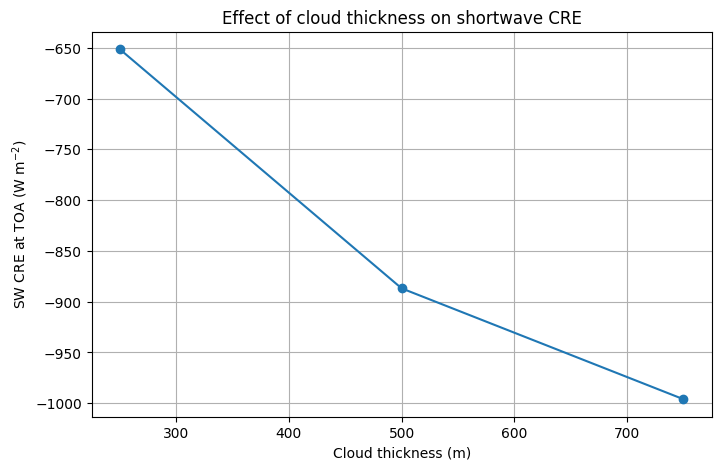

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    cloud_thickness_values,
    cre_thickness_df["CRE_SW_TOA"],
    marker="o"
)

plt.xlabel("Cloud thickness (m)")
plt.ylabel(r"SW CRE at TOA (W m$^{-2}$)")
plt.title("Effect of cloud thickness on shortwave CRE")
plt.grid(True)
plt.show()

# AI Usage

Tool: ChatGPT

Usage:

1. I used AI for all the plotting and figures in this homework.
2. AI was used to create the summary table for the results of the model.
3. AI was used to clean up the markdown text and write all the equations in the correct format.
4. AI was used to create the atmospheric layers dictionary and add the layer boundary logic to the main model.